# 08 — Stored versus fully connected edges

A controlled 2×2 experiment on **Reid** and **mixed-temperature dePablo**. For each dataset, the same split, seed, architecture, reconstruction target, and latent propagator are trained once with stored elastic edges and once with directed fully connected edges. The AE and propagator each train on up to 100 frames/transitions per training network; rollout quality is evaluated through a nominal 200-step horizon.

In [1]:
%matplotlib inline
import os, sys
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src' / 'lss').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lss.latent.capacity import evaluate_experiment
from lss.latent.experiment import ground_truth_p_ratio, run_latent_experiment, seed_everything
from lss.latent.training import encode_frame_latent
from lss.utils import resolve_device
DEVICE = resolve_device('auto')
DEVICE

/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

## Matched experiment settings

`FORCE_TRAIN=True` intentionally retrains all four cases. Complete graphs use batch size 1 because their edge count scales as N(N−1). Checkpoints include the edge mode, so stored and complete results cannot be mixed.

In [2]:
BASE_SEED = 20260721
FORCE_TRAIN = False
TRAIN_COUNT, VAL_COUNT = 20, 20
LATENT_DIM, LATENT_TOKENS, HIDDEN_SIZE = 2, 32, 96
AE_TRAIN_FRAMES = 100
DYN_TRAIN_TRANSITIONS = 100
AE_MAX_EPOCHS, AE_PATIENCE = 80, 8
DYN_MAX_EPOCHS, DYN_PATIENCE = 80, 8
ROLLOUT_STEPS = [10, 20, 50, 100, 150, 200]
ROLLOUT_EVAL_SIMS = 30
LATENT_ANALYSIS_SIMS = 30
LATENT_ANALYSIS_FRAMES = 12
OUTPUT = PROJECT_ROOT / 'notebooks' / 'results' / '08_complete_edge_rollout_comparison'
OUTPUT.mkdir(parents=True, exist_ok=True)
DATASETS = {
    'reid': ('Reid', PROJECT_ROOT / 'data' / 'reid_200_frames.pt'),
    'depablo_mixed_temp': ('dePablo mixed-T', PROJECT_ROOT / 'data' / 'depablo-10k-mix-temp.pt'),
}
EDGE_MODES = ('stored', 'complete')
for _, path in DATASETS.values(): assert path.exists(), path

In [3]:
def build_case(dataset_key, label, path, edge_mode, seed):
    case_key = f'{dataset_key}_{edge_mode}'
    case_dir = OUTPUT / case_key
    case_dir.mkdir(parents=True, exist_ok=True)
    cache = case_dir / (
        f'rollout_{edge_mode}_cv{LATENT_DIM}_train{TRAIN_COUNT}_'
        f'frames{AE_TRAIN_FRAMES}_dyn{DYN_TRAIN_TRANSITIONS}_seed{seed}.pt'
    )
    cfg = {
        'dataset_name': dataset_key, 'split_seed': seed, 'model_seed': seed, 'repeat_idx': 1,
        'device': str(DEVICE), 'pos_dim': 2, 'batch_graphs': 1 if edge_mode == 'complete' else 4,
        'frame_skip': 1, 'latent_dim': LATENT_DIM, 'latent_tokens': LATENT_TOKENS,
        'hidden_size': HIDDEN_SIZE, 'autoencoder_model': 'attention', 'edge_mode': edge_mode,
        'ae_target_mode': 'normalized_delta', 'node_feature_mode': 'normalized_delta',
        'ae_max_train_frames_per_sim': AE_TRAIN_FRAMES,
        'dyn_max_train_transitions_per_sim': DYN_TRAIN_TRANSITIONS,
        'ae_max_epochs': AE_MAX_EPOCHS, 'ae_patience': AE_PATIENCE,
        'ae_lr': 5e-5, 'ae_weight_decay': 1e-5,
        'dyn_max_epochs': DYN_MAX_EPOCHS, 'dyn_patience': DYN_PATIENCE,
        'dyn_lr': 3e-5, 'dyn_weight_decay': 1e-4, 'early_stop_min_delta': 1e-5,
        'propagator_use_static_context': True, 'graph_context_dim': 16,
        'propagator_context_include_temperature': False,
        'propagator_objective': 'one_step', 'propagator_model': 'delta_mlp',
        'propagator_loss': 'delta', 'propagator_standardize_latent': False,
        'initial_velocity': 'zero', 'rollout_steps_grid': ROLLOUT_STEPS,
        'rollout_eval_max_sims_per_split': ROLLOUT_EVAL_SIMS,
        'temperature_pratio_estimator': 'robust', 'temperature_pratio_min_fit_frames': 8,
        'temperature_pratio_min_driven_strain_range': 1e-3, 'temperature_pratio_smooth_window': 5,
        'should_rollout': True, 'should_train_propagator': True,
        'force_train': FORCE_TRAIN, 'cache_path': str(cache),
    }
    source = {
        'dataset_name': dataset_key, 'source_name': label,
        'label': f'{label} | {edge_mode} edges', 'path': str(path),
        'dataset_mixture': [{'name': dataset_key, 'label': label, 'path': str(path),
                             'train_count': TRAIN_COUNT, 'val_count': VAL_COUNT}],
        'target_mode': 'normalized_delta', 'ae_target_mode': 'normalized_delta',
        'node_feature_mode': 'normalized_delta', 'edge_mode': edge_mode,
        'latent_dim': LATENT_DIM, 'latent_tokens': LATENT_TOKENS, 'hidden_size': HIDDEN_SIZE,
        'autoencoder_model': 'attention', 'ae_max_train_frames_per_sim': AE_TRAIN_FRAMES,
        'dyn_max_train_transitions_per_sim': DYN_TRAIN_TRANSITIONS,
        'ae_max_epochs': AE_MAX_EPOCHS, 'ae_patience': AE_PATIENCE,
        'dyn_max_epochs': DYN_MAX_EPOCHS, 'dyn_patience': DYN_PATIENCE,
        'ae_lr': cfg['ae_lr'], 'ae_weight_decay': cfg['ae_weight_decay'],
        'dyn_lr': cfg['dyn_lr'], 'dyn_weight_decay': cfg['dyn_weight_decay'],
        'model_seed': seed, 'repeat_idx': 1,
    }
    return case_key, cfg, source

## Train the four cases

Cases run sequentially. Stored and complete variants of a dataset deliberately share a seed, giving them the same train/validation/test split and initial random weights.

In [4]:
results = {}
case_meta = {}
for dataset_index, (dataset_key, (label, path)) in enumerate(DATASETS.items()):
    seed = BASE_SEED + 101 * dataset_index
    for edge_mode in EDGE_MODES:
        case_key, cfg, source = build_case(dataset_key, label, path, edge_mode, seed)
        print(f'\n### {case_key}', flush=True)
        seed_everything(seed)
        results[case_key] = run_latent_experiment(source, cfg, device=DEVICE)
        case_meta[case_key] = {'dataset': dataset_key, 'dataset_label': label,
                               'edge_mode': edge_mode, 'seed': seed, 'cfg': cfg}
pd.concat([r['split_info'].assign(case=k) for k, r in results.items()], ignore_index=True)


### reid_stored
loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/08_complete_edge_rollout_comparison/reid_stored/rollout_stored_cv2_train20_frames100_dyn100_seed20260721.pt

### reid_complete
loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/08_complete_edge_rollout_comparison/reid_complete/rollout_complete_cv2_train20_frames100_dyn100_seed20260721.pt

### depablo_mixed_temp_stored
loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/08_complete_edge_rollout_comparison/depablo_mixed_temp_stored/rollout_stored_cv2_train20_frames100_dyn100_seed20260822.pt

### depablo_mixed_temp_complete
loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/08_complete_edge_rollout_comparison/depablo_mixed_temp_complete/rollout_complete_cv2_train20_frames100_dyn100_seed20260822.pt


,source,path,total,train,reserved_train_pool,val,test,case
0,reid,/home/alexz/Documents/course_project/data/reid...,102,20,20,20,62,reid_stored
1,reid,/home/alexz/Documents/course_project/data/reid...,102,20,20,20,62,reid_complete
2,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,20,20,20,260,depablo_mixed_temp_stored
3,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,20,20,20,260,depablo_mixed_temp_complete


## Latent–p-ratio correlations

For the first 30 test networks, encode 12 evenly spaced frames from the first 100 stored frames. Compare p-ratio with initial coordinates, final early-window coordinates, and coordinate slopes. Coordinate signs may flip between runs, so the summary also reports |r|.

In [5]:
def latent_descriptors(case_key, result):
    meta, cfg = case_meta[case_key], case_meta[case_key]['cfg']
    rows = []
    with torch.no_grad():
        for sim_index, sim in enumerate(result['test_data'][:LATENT_ANALYSIS_SIMS]):
            stop = min(AE_TRAIN_FRAMES, len(sim)) - 1
            frame_ids = np.unique(np.linspace(0, stop, LATENT_ANALYSIS_FRAMES, dtype=int))
            z = np.stack([encode_frame_latent(
                result['ae'], sim, int(frame), pos_dim=2,
                node_feature_mode='normalized_delta', normalizers=result['normalizers'],
                device=DEVICE,
            ).cpu().numpy() for frame in frame_ids])
            time = frame_ids.astype(float)
            time = (time - time.mean()) / max(np.ptp(time), 1.0)
            slope = (time[:, None] * z).sum(0) / np.square(time).sum()
            rows.append({
                'case': case_key, 'dataset': meta['dataset'], 'dataset_label': meta['dataset_label'],
                'edge_mode': meta['edge_mode'], 'sim_index': sim_index,
                'p_ratio': ground_truth_p_ratio(sim, dataset_name=meta['dataset'], cfg=cfg),
                'initial_z0': z[0, 0], 'initial_z1': z[0, 1],
                'early_final_z0': z[-1, 0], 'early_final_z1': z[-1, 1],
                'slope_z0': slope[0], 'slope_z1': slope[1],
            })
    return pd.DataFrame(rows).dropna()
descriptor_df = pd.concat([latent_descriptors(k, r) for k, r in results.items()], ignore_index=True)
features = ['initial_z0', 'initial_z1', 'early_final_z0', 'early_final_z1', 'slope_z0', 'slope_z1']
corr_rows = []
for (dataset, edge_mode), group in descriptor_df.groupby(['dataset', 'edge_mode']):
    for feature in features:
        r = group[feature].corr(group.p_ratio)
        corr_rows.append({'dataset': dataset, 'edge_mode': edge_mode, 'feature': feature,
                          'pearson_r': r, 'abs_pearson_r': abs(r)})
latent_corr = pd.DataFrame(corr_rows)
descriptor_df.to_csv(OUTPUT / 'latent_descriptors.csv', index=False)
latent_corr.to_csv(OUTPUT / 'latent_pratio_correlations.csv', index=False)
display(latent_corr.pivot_table(index=['dataset', 'feature'], columns='edge_mode', values='pearson_r').round(3))

edge_mode                          complete  stored
dataset            feature                         
depablo_mixed_temp early_final_z0    -0.765  -0.941
                   early_final_z1    -0.800   0.791
                   initial_z0         0.216  -0.948
                   initial_z1         0.246   0.837
                   slope_z0          -0.779  -0.858
                   slope_z1          -0.892  -0.668
reid               early_final_z0    -0.991  -0.949
                   early_final_z1     0.963  -0.873
                   initial_z0        -0.404  -0.924
                   initial_z1         0.055  -0.909
                   slope_z0          -0.984  -0.954
                   slope_z1           0.956  -0.556

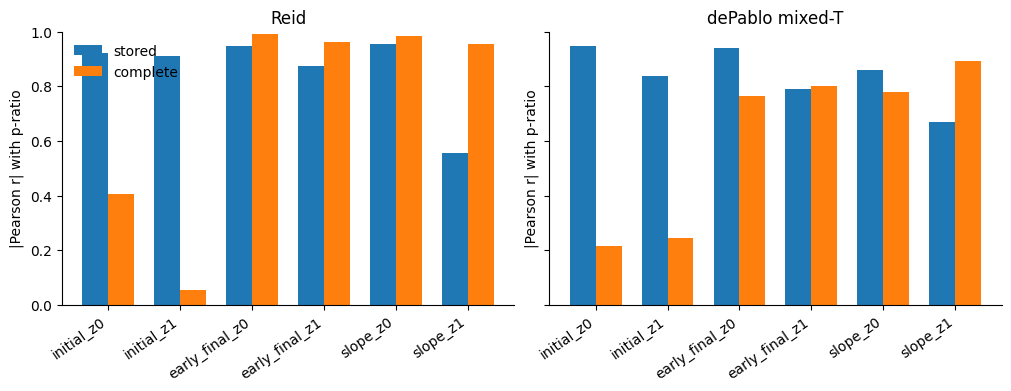

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True, constrained_layout=True)
for ax, dataset in zip(axes, DATASETS):
    plot = latent_corr[latent_corr['dataset'].eq(dataset)].pivot(index='feature', columns='edge_mode', values='abs_pearson_r')
    plot = plot.reindex(features)
    x = np.arange(len(plot)); width = .36
    for offset, mode in zip((-.5, .5), EDGE_MODES):
        ax.bar(x + offset * width, plot[mode], width, label=mode)
    ax.set_xticks(x, plot.index, rotation=35, ha='right')
    ax.set(title=DATASETS[dataset][0], ylabel='|Pearson r| with p-ratio', ylim=(0, 1))
    ax.spines[['top', 'right']].set_visible(False)
axes[0].legend(frameon=False)
plt.show()

## Rollout comparison

The decisive comparison is paired within each dataset: complete versus stored edges at the same horizon. Position R² measures improvement over predicting the undeformed initial structure; p-ratio Pearson r measures whether rollout preserves network-to-network response ordering.

In [8]:
rollout_parts = []
for case_key, result in results.items():
    if result['rollout_stats'].empty:
        print(f'Evaluating cached rollout: {case_key}', flush=True)
        result = evaluate_experiment(result, case_meta[case_key]['cfg'], device=DEVICE)
        results[case_key] = result
    table = result['rollout_stats'].copy()
    if table.empty:
        raise RuntimeError(f'Rollout evaluation returned no rows for {case_key}')
    table = table.assign(
        case=case_key,
        dataset=case_meta[case_key]['dataset'],
        edge_mode=case_meta[case_key]['edge_mode'],
    )
    rollout_parts.append(table)
rollout_df = pd.concat(rollout_parts, ignore_index=True)
required = {'split', 'rollout_steps', 'p_ratio_r2', 'p_ratio_pearson'}
missing = required.difference(rollout_df.columns)
if missing:
    raise RuntimeError(f'Rollout table is missing required columns: {sorted(missing)}')
rollout_df.to_csv(OUTPUT / 'rollout_comparison.csv', index=False)
test_rollout = rollout_df[rollout_df['split'].eq('test')].copy()
display(test_rollout[['dataset', 'edge_mode', 'rollout_steps', 'rollout_position_r2',
                      'p_ratio_r2', 'p_ratio_pearson', 'final_pos_mse']].round(4))

Evaluating cached rollout: reid_complete
Evaluating cached rollout: depablo_mixed_temp_stored
Evaluating cached rollout: depablo_mixed_temp_complete


,dataset,edge_mode,rollout_steps,rollout_position_r2,p_ratio_r2,p_ratio_pearson,final_pos_mse
0,reid,stored,10,0.6337,0.0704,0.7989,0.0000
1,reid,stored,20,0.7501,0.6919,0.8920,0.0000
2,reid,stored,50,0.8315,0.7632,0.8852,0.0001
3,reid,stored,100,0.7968,-0.2299,0.4746,0.0004
4,reid,stored,150,0.6176,-1.7247,0.1137,0.0017
5,reid,stored,199,0.0000,-3.4166,-0.0178,0.0667
6,reid,complete,10,0.8494,0.4252,0.7626,0.0000
7,reid,complete,20,0.9087,0.5525,0.8172,0.0000
8,reid,complete,50,0.8974,0.5132,0.8343,0.0000
9,reid,complete,100,0.8718,0.4661,0.8194,0.0002


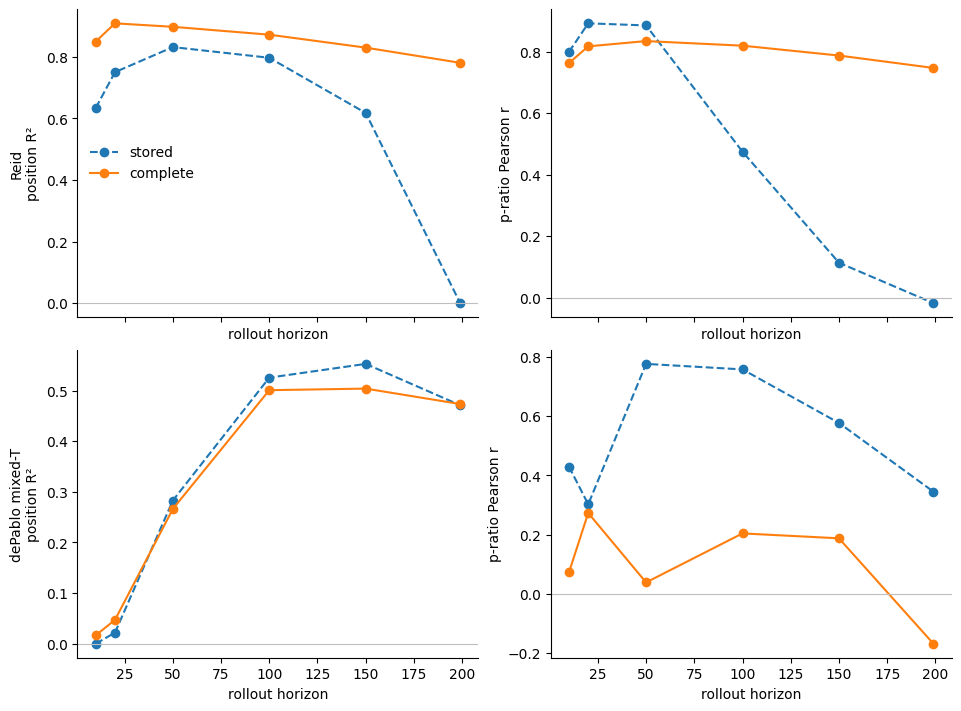

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.0), sharex=True, constrained_layout=True)
for row, dataset in enumerate(DATASETS):
    for edge_mode, linestyle in zip(EDGE_MODES, ('--', '-')):
        group = test_rollout[test_rollout['dataset'].eq(dataset) & test_rollout['edge_mode'].eq(edge_mode)].sort_values('rollout_steps')
        axes[row, 0].plot(group.rollout_steps, group.rollout_position_r2, marker='o', ls=linestyle, label=edge_mode)
        axes[row, 1].plot(group.rollout_steps, group.p_ratio_pearson, marker='o', ls=linestyle, label=edge_mode)
    axes[row, 0].set(ylabel=f"{DATASETS[dataset][0]}\nposition R²")
    axes[row, 1].set(ylabel='p-ratio Pearson r')
for ax in axes.flat:
    ax.set_xlabel('rollout horizon')
    ax.axhline(0, color='.75', lw=.8)
    ax.spines[['top', 'right']].set_visible(False)
axes[0, 0].legend(frameon=False)
plt.show()